# HVIA Task 01 — Olist Business Discovery

### Data Analysis Internship — Trial Task

**Prepared for:** HVIA — Data & AI Solutions  
**Dataset:** Olist Brazilian E-Commerce Public Dataset

---

This notebook explores Olist's public e-commerce dataset to understand the business,
investigate customer and seller behavior, identify business-relevant patterns,
and translate the findings into potential Data & AI opportunities.

**Workflow:**   
**Understand → Analyze → Propose → Pitch**

## 1. Company Research — Who is Olist?

**Olist** is a Brazilian retail-technology company, founded in 2015 in Curitiba, Brazil. It started from a
simple problem: small and medium-sized Brazilian merchants struggled to sell on the country's major
marketplaces (Mercado Livre, Amazon, Shopee, Magazine Luiza, etc.) because each one has its own registration,
catalog rules, and operational requirements. Olist built a single hub that lets a small seller list a product
once and reach 170+ marketplaces at the same time.

Over time, Olist grew from a "marketplace connector" into a broader commerce operating system for small
sellers, covering:

- **Marketplace Hub** – connects sellers to 170+ marketplaces through one integration
- **Olist Shops** – an ecommerce storefront builder for the seller's own online store
- **ERP** – order, inventory, and business management in one place
- **Olist Pay & Business Credit** – payments and working-capital loans for sellers
- **Logistics & Shipping (fulfillment)** – warehousing and a delivery network
- **AI-native features** – automated pricing, recommendations, and operational tools

**Business model:** Olist does not sell its own products. It is a B2B SaaS + marketplace-integrator that
earns commission/subscription revenue by helping thousands of small Brazilian sellers reach customers across
many sales channels at once, instead of each seller having to manage every marketplace separately. Olist
became a Brazilian "unicorn" after raising over $300M from investors including SoftBank, Goldman Sachs, and
Wellington Management.

**Who are its customers?** Olist's direct customers are the **sellers** (small/medium Brazilian merchants),
not the end shoppers. The end shoppers are the customers of the marketplaces (Mercado Livre, Amazon, etc.)
that Olist connects sellers to — so Olist's product has to satisfy two audiences at once: sellers need it to
be easy and profitable to use, and the marketplaces' end customers need a good delivery/purchase experience,
because that experience directly affects seller ratings on those platforms.

**Why this matters for our analysis:** Olist sits in the middle of a three-sided network — **sellers**,
**marketplaces/customers**, and **logistics/payments** — so the dataset used in this notebook (orders, items,
payments, reviews, sellers, products, geolocation) is essentially a snapshot of that entire operating system
in action.

## 2. Dataset Understanding

The Olist Brazilian E-Commerce Public Dataset contains approximately 100,000
orders from the 2016–2018 period and is distributed across 9 CSV files.

Each table represents a different analytical grain, so understanding the
relationships between tables is essential before calculating KPIs.

### How the Tables Connect

The main analytical flow can be represented as:

**customers → orders → order_items → products**  
**　　　　　　　　　↓**  
**　　　　　　　 sellers**

**orders → payments**  
**orders → reviews**

The category translation table enriches product categories, while geolocation
can be used as an optional geographic lookup.

The main analysis is centered around orders and order items because they connect
customer, product, seller, payment, and review information.

## 3. Data Loading & Initial Setup

The nine provided CSV files were loaded using pandas. Before starting the
analysis, the datasets were checked for their size and structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

dfs = 'dataset/' 

## 4. Data Audit & Quality

Before analyzing the business, the datasets were checked for:

- Row and column counts
- Missing values
- Duplicate records
- Date completeness
- Key relationships between tables

Missing values were not automatically treated as errors because missingness can
sometimes have business meaning. For example, delivery timestamps may be unavailable
for orders that did not complete the delivery process.

In [3]:
orders      = pd.read_csv(dfs + 'olist_orders_dataset.csv')
items       = pd.read_csv(dfs + 'olist_order_items_dataset.csv')
payments    = pd.read_csv(dfs + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(dfs + 'olist_order_reviews_dataset.csv')
customers   = pd.read_csv(dfs + 'olist_customers_dataset.csv')
products    = pd.read_csv(dfs + 'olist_products_dataset.csv')
sellers     = pd.read_csv(dfs + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(dfs + 'olist_geolocation_dataset.csv')
cat_trans   = pd.read_csv(dfs + 'product_category_name_translation.csv')

for name, df in [('orders', orders), ('items', items), ('payments', payments),
                  ('reviews', reviews), ('customers', customers), ('products', products),
                  ('sellers', sellers), ('geolocation', geolocation), ('cat_trans', cat_trans)]:
    print(f'{name:12s} {df.shape[0]:>8,} rows , {df.shape[1]} columns')

orders         99,441 rows , 8 columns
items         112,650 rows , 7 columns
payments      103,886 rows , 5 columns
reviews        99,224 rows , 7 columns
customers      99,441 rows , 5 columns
products       32,951 rows , 9 columns
sellers         3,095 rows , 4 columns
geolocation  1,000,163 rows , 5 columns
cat_trans          71 rows , 2 columns


In [4]:
# Basic data quality audit

audit = []

for name, df in [
    ('orders', orders),
    ('items', items),
    ('payments', payments),
    ('reviews', reviews),
    ('customers', customers),
    ('products', products),
    ('sellers', sellers),
    ('geolocation', geolocation),
    ('category_translation', cat_trans)
]:
    audit.append({
        'table': name,
        'rows': len(df),
        'columns': df.shape[1],
        'missing_values': df.isna().sum().sum(),
        'duplicate_rows': df.duplicated().sum()
    })

audit_df = pd.DataFrame(audit)
audit_df

,table,rows,columns,missing_values,duplicate_rows
0,orders,99441,8,4908,0
1,items,112650,7,0,0
2,payments,103886,5,0,0
3,reviews,99224,7,145903,0
4,customers,99441,5,0,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
7,geolocation,1000163,5,0,261831
8,category_translation,71,2,0,0


In [5]:
# Identify the most important missing-value patterns

missing_summary = []

for name, df in [
    ('orders', orders),
    ('items', items),
    ('payments', payments),
    ('reviews', reviews),
    ('customers', customers),
    ('products', products),
    ('sellers', sellers),
    ('geolocation', geolocation),
    ('category_translation', cat_trans)
]:
    for column in df.columns:
        missing_count = df[column].isna().sum()

        if missing_count > 0:
            missing_summary.append({
                'table': name,
                'column': column,
                'missing_count': missing_count,
                'missing_pct': round(missing_count / len(df) * 100, 2)
            })

missing_df = pd.DataFrame(missing_summary)

missing_df.sort_values('missing_pct', ascending=False).head(15)

,table,column,missing_count,missing_pct
3,reviews,review_comment_title,87656,88.34
4,reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
6,products,product_name_lenght,610,1.85
5,products,product_category_name,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


### Date Preparation

Order timestamps were converted from strings to datetime values so that delivery
durations, delays, and time-based trends could be calculated.

In [6]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for i in date_cols:
    orders[i] = pd.to_datetime(orders[i], errors='coerce')

print('Order status:')
print(orders['order_status'].value_counts())
print()
print('Date range:', 'from', orders['order_purchase_timestamp'].min(), 'to', orders['order_purchase_timestamp'].max())

Order status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range: from 2016-09-04 21:15:19 to 2018-10-17 17:30:18


## 5. Data Relationships & Analytical Grain

To support the exploratory analysis, the tables were combined into an item-level
analytical dataset.

> **One row in `master` represents one item within an order.**

Payment records were aggregated to the order level before merging because an order
can contain multiple payment records.

Reviews were also aggregated to the order level to avoid unnecessary row
multiplication during the merge.

In [7]:
products_en = products.merge(
    cat_trans,
    on='product_category_name',
    how='left'
)

master = (
    items
    .merge(orders, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(products_en, on='product_id', how='left')
    .merge(sellers, on='seller_id', how='left')
)

# One row per order
pay_per_order = (
    payments
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'order_payment_total'})
)

# One row per order
rev_per_order = (
    reviews
    .groupby('order_id', as_index=False)['review_score']
    .mean()
    .rename(columns={'review_score': 'order_review_score'})
)

master = master.merge(
    pay_per_order,
    on='order_id',
    how='left'
)

master = master.merge(
    rev_per_order,
    on='order_id',
    how='left'
)

# Item-level value
master['item_total'] = master['price'] + master['freight_value']

print('Original order_items rows:', len(items))
print('Master table shape:', master.shape)

print('\nMissing keys after merge:')
print('order_id:', master['order_id'].isna().sum())
print('customer_id:', master['customer_id'].isna().sum())
print('product_id:', master['product_id'].isna().sum())
print('seller_id:', master['seller_id'].isna().sum())

master[ [ 'order_id', 'order_status', 'price', 'freight_value', 'item_total', 'order_payment_total',
          'product_category_name_english', 'customer_state', 'seller_state', 'order_review_score']].head()

Original order_items rows: 112650
Master table shape: (112650, 33)

Missing keys after merge:
order_id: 0
customer_id: 0
product_id: 0
seller_id: 0


,order_id,order_status,price,freight_value,item_total,order_payment_total,product_category_name_english,customer_state,seller_state,order_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,58.90,13.29,72.19,72.19,cool_stuff,RJ,SP,5.0
1,00018f77f2f0320c557190d7a144bdd3,delivered,239.90,19.93,259.83,259.83,pet_shop,SP,SP,4.0
2,000229ec398224ef6ca0657da4fc703e,delivered,199.00,17.87,216.87,216.87,furniture_decor,MG,MG,5.0
3,00024acbcdf0a6daa1e931b038114c75,delivered,12.99,12.79,25.78,25.78,perfumery,SP,SP,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,199.90,18.14,218.04,218.04,garden_tools,SP,PR,5.0


In [8]:
# Validate important table relationships

print("Customer records:", len(customers))
print("Unique customer_id:", customers['customer_id'].nunique())
print("Unique customer_unique_id:", customers['customer_unique_id'].nunique())

items_per_order = items.groupby('order_id').size()
print("\nOrders with multiple items:", (items_per_order > 1).sum())

payments_per_order = payments.groupby('order_id').size()
print("Orders with multiple payment records:", (payments_per_order > 1).sum())

reviews_per_order = reviews.groupby('order_id').size()
print("Orders with multiple review records:", (reviews_per_order > 1).sum())

print("\nGeolocation duplicate rows:", geolocation.duplicated().sum())

Customer records: 99441
Unique customer_id: 99441
Unique customer_unique_id: 96096

Orders with multiple items: 9803
Orders with multiple payment records: 2961
Orders with multiple review records: 547

Geolocation duplicate rows: 261831


In [9]:
# Create the delivered-order analysis dataset

delivered = master[
    master['order_status'] == 'delivered'
].copy()

print("Delivered item rows:", len(delivered))
print("Delivered orders:", delivered['order_id'].nunique())

Delivered item rows: 110197
Delivered orders: 96478


### Merge Validation

The resulting analytical table was validated against the original `order_items`
table to ensure that the joins did not unexpectedly multiply rows or create
missing relationships.

## 6. Business Questions

Rather than starting with a fixed list of KPIs, the analysis focuses on business
questions that could have practical implications for Olist:

1. How has delivered order volume evolved over time?
2. Where is customer demand geographically concentrated?
3. How common are late deliveries?
4. Is delivery performance associated with customer satisfaction?
5. Which product categories contribute the most order value?
6. How is order value distributed across sellers?
7. What level of repeat purchasing appears in the observed period?
8. What does payment behavior reveal about the marketplace ecosystem?

## 7. Exploratory Data Analysis

The analysis below answers the business questions using order, customer, product,
seller, payment, and review data.

### 7.1 Order Volume Over Time

This analysis examines how delivered order volume evolved across the observed period
and identifies periods of higher or lower activity.

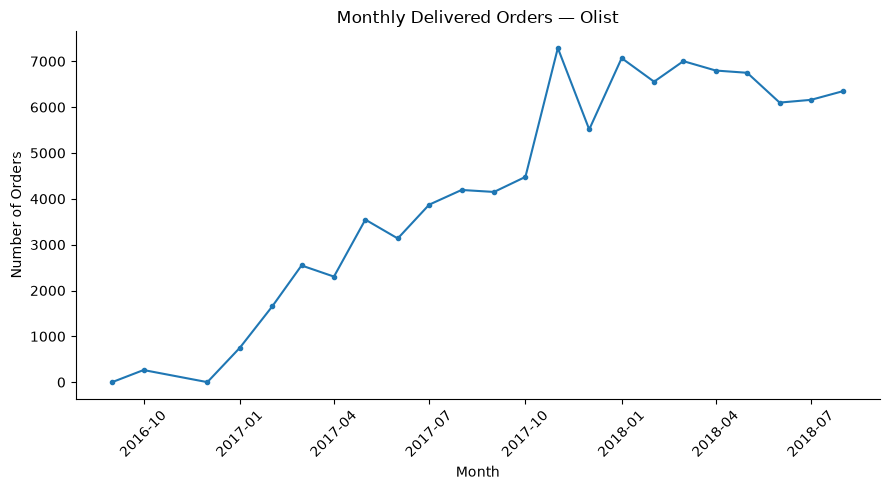

Total delivered orders: 96,478
Total order value (items + freight): R$ 15,419,774
Peak month: 2017-11 with 7,289 orders


In [10]:
# Create order-level value
order_value = (
    items
    .assign(item_total=items['price'] + items['freight_value'])
    .groupby('order_id', as_index=False)
    .agg(
        order_value=('item_total', 'sum'),
        total_items=('order_item_id', 'count')
    )
)

# Delivered orders only
delivered_orders = (
    orders[orders['order_status'] == 'delivered']
    .copy()
    .merge(order_value, on='order_id', how='left')
)

# Monthly aggregation
monthly = (
    delivered_orders
    .assign(
        month=delivered_orders['order_purchase_timestamp']
        .dt.to_period('M')
        .dt.to_timestamp()
    )
    .groupby('month')
    .agg(
        orders=('order_id', 'nunique'),
        order_value=('order_value', 'sum')
    )
    .reset_index()
)

monthly['avg_order_value'] = (
    monthly['order_value'] / monthly['orders']
)

# Plot
fig, ax = plt.subplots()

ax.plot(
    monthly['month'],
    monthly['orders'],
    marker='o',
    markersize=3
)

ax.set_title('Monthly Delivered Orders — Olist')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary
peak_idx = monthly['orders'].idxmax()

print(f"Total delivered orders: {delivered_orders['order_id'].nunique():,}")
print(
    f"Total order value (items + freight): "
    f"R$ {delivered_orders['order_value'].sum():,.0f}"
)
print(
    f"Peak month: "
    f"{monthly.loc[peak_idx, 'month'].strftime('%Y-%m')} "
    f"with {monthly.loc[peak_idx, 'orders']:,} orders"
)

### 7.2 Geographic Demand

Customer orders are analyzed by state to understand where demand is concentrated
geographically.

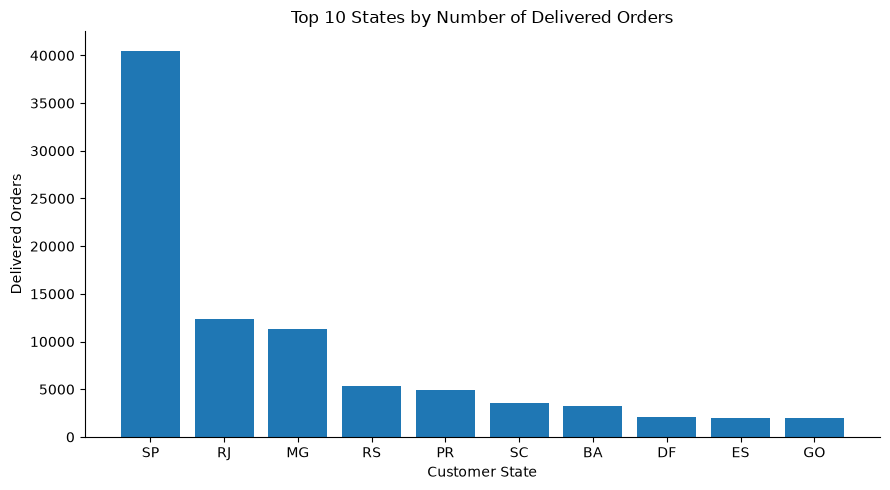

Top state: SP — 40,501 orders (42.0% of all delivered orders)
Top 3 states account for 66.5% of all delivered orders


In [11]:
delivered_customer_orders = (
    orders[orders['order_status'] == 'delivered']
    [['order_id', 'customer_id']]
    .merge(
        customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
)

state_orders = (
    delivered_customer_orders
    .groupby('customer_state')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

top10 = state_orders.head(10)

fig, ax = plt.subplots()

ax.bar(top10.index, top10.values)

ax.set_title('Top 10 States by Number of Delivered Orders')
ax.set_xlabel('Customer State')
ax.set_ylabel('Delivered Orders')

plt.tight_layout()
plt.show()

# summary
top_state_share = (
    state_orders.iloc[0] / state_orders.sum() * 100
)

top3_share = (
    state_orders.head(3).sum() / state_orders.sum() * 100
)

print(
    f"Top state: {state_orders.index[0]} — "
    f"{state_orders.iloc[0]:,} orders "
    f"({top_state_share:.1f}% of all delivered orders)"
)

print(
    f"Top 3 states account for "
    f"{top3_share:.1f}% of all delivered orders"
)

### 7.3 Delivery Performance

Delivery performance is evaluated by comparing the actual customer delivery date
with the estimated delivery date.

Two measures are used:

- **Delivery duration:** purchase → customer delivery
- **Delivery delay:** actual delivery → estimated delivery date

An order is classified as late when its actual delivery date is after the estimated
delivery date.

In [12]:
# Review score at order level
order_reviews = (
    reviews
    .groupby('order_id', as_index=False)
    .agg(
        order_review_score=('review_score', 'mean')
    )
)

# Delivered orders with delivery dates
delivery_analysis = (
    orders[orders['order_status'] == 'delivered']
    [
        [
            'order_id',
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ]
    .dropna(
        subset=[
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    )
    .merge(order_reviews, on='order_id', how='left')
)

# Delivery metrics
delivery_analysis['delivery_days'] = (
    delivery_analysis['order_delivered_customer_date']
    - delivery_analysis['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

delivery_analysis['delay_days'] = (
    delivery_analysis['order_delivered_customer_date']
    - delivery_analysis['order_estimated_delivery_date']).dt.total_seconds() / (24 * 60 * 60)

delivery_analysis['was_late'] = (delivery_analysis['delay_days'] > 0)

# Overall late rate
late_share = (delivery_analysis['was_late'].mean() * 100)

avg_delivery_days = (delivery_analysis['delivery_days'].mean())

print(f"{late_share:.1f}% of delivered orders arrived " f"after the estimated delivery date")

print(f"Average delivery time: {avg_delivery_days:.1f} days")

8.1% of delivered orders arrived after the estimated delivery date
Average delivery time: 12.6 days


### 7.4 Delivery Performance & Customer Satisfaction

The analysis compares review scores between orders that arrived on-time/early and
orders that arrived after the estimated delivery date.

This comparison is treated as an **association rather than a causal relationship**.

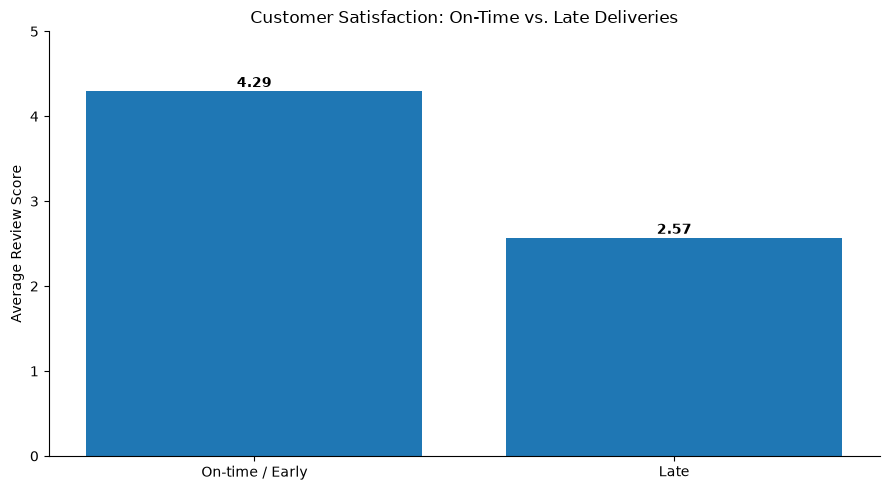

Average review score — On-time/Early: 4.29
Average review score — Late: 2.57
Difference: 1.73 points


In [13]:
review_analysis = delivery_analysis.dropna(
    subset=['order_review_score']
)

avg_score_on_time = (
    review_analysis
    .loc[~review_analysis['was_late'], 'order_review_score']
    .mean()
)

avg_score_late = (
    review_analysis
    .loc[review_analysis['was_late'], 'order_review_score']
    .mean()
)

fig, ax = plt.subplots()

values = [avg_score_on_time, avg_score_late]

ax.bar(
    ['On-time / Early', 'Late'],
    values
)

ax.set_ylabel('Average Review Score')
ax.set_title('Customer Satisfaction: On-Time vs. Late Deliveries')
ax.set_ylim(0, 5)

for i, value in enumerate(values):
    ax.text(
        i,
        value + 0.05,
        f'{value:.2f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print(f"Average review score — On-time/Early: {avg_score_on_time:.2f}")
print(f"Average review score — Late: {avg_score_late:.2f}")
print(f"Difference: " f"{avg_score_on_time - avg_score_late:.2f} points")

### 7.5 Product Category Performance

Product categories are compared using total order value and number of orders.
Average review scores are used as a supporting customer-experience metric.

In [14]:
category_value = (
    delivered
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(
        order_value=('item_total', 'sum'),
        orders=('order_id', 'nunique')
    )
    .sort_values('order_value', ascending=False)
)

top_categories = category_value.head(10)

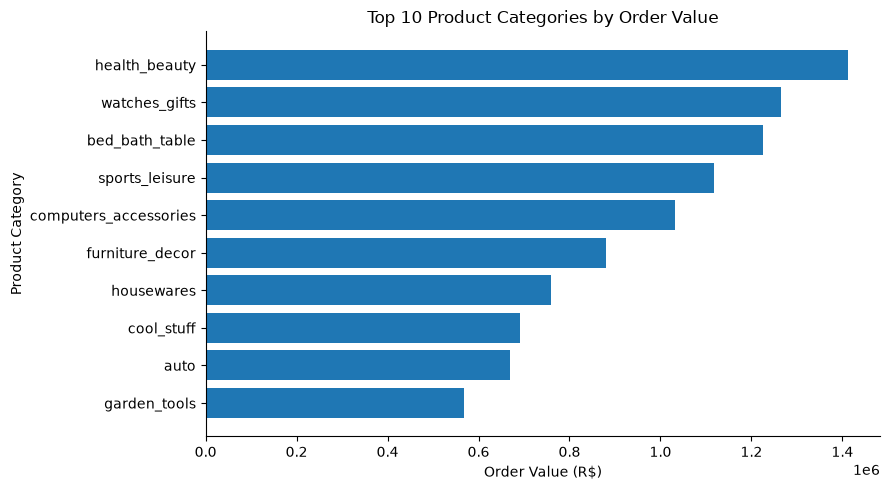

In [15]:
fig, ax = plt.subplots()

ax.barh(
    top_categories.index[::-1],
    top_categories['order_value'][::-1]
)

ax.set_title('Top 10 Product Categories by Order Value')
ax.set_xlabel('Order Value (R$)')
ax.set_ylabel('Product Category')

plt.tight_layout()
plt.show()

In [16]:
category_reviews = (
    delivered[
        [
            'order_id',
            'product_category_name_english',
            'order_review_score'
        ]
    ]
    .dropna(subset=['product_category_name_english', 'order_review_score'])
    .drop_duplicates(
        subset=['order_id', 'product_category_name_english']
    )
    .groupby('product_category_name_english')
    .agg(
        avg_review=('order_review_score', 'mean')
    )
)

category_analysis = (
    category_value
    .join(category_reviews)
    .head(10)
)

category_analysis.round(2)

,order_value,orders,avg_review
product_category_name_english,,,
health_beauty,1412089.53,8647,4.23
watches_gifts,1264333.12,5495,4.12
bed_bath_table,1225209.26,9272,4.00
sports_leisure,1118256.91,7530,4.23
computers_accessories,1032723.77,6530,4.08
furniture_decor,880329.92,6307,4.06
housewares,758392.25,5743,4.19
cool_stuff,691680.89,3559,4.22
auto,669454.75,3810,4.15


### 7.6 Payment Behavior

Payment records are explored to understand the distribution of payment methods and
installment behavior.

Because one order may contain multiple payment records, payment-method analysis
is performed at the payment-record level unless otherwise specified.

In [17]:
payment_type_summary = (
    payments
    .groupby('payment_type')
    .agg(
        payment_records=('order_id', 'count'),
        total_payment_value=('payment_value', 'sum')
    )
    .sort_values('total_payment_value', ascending=False)
)

payment_type_summary

,payment_records,total_payment_value
payment_type,,
credit_card,76795,12542084.19
boleto,19784,2869361.27
voucher,5775,379436.87
debit_card,1529,217989.79
not_defined,3,0.00


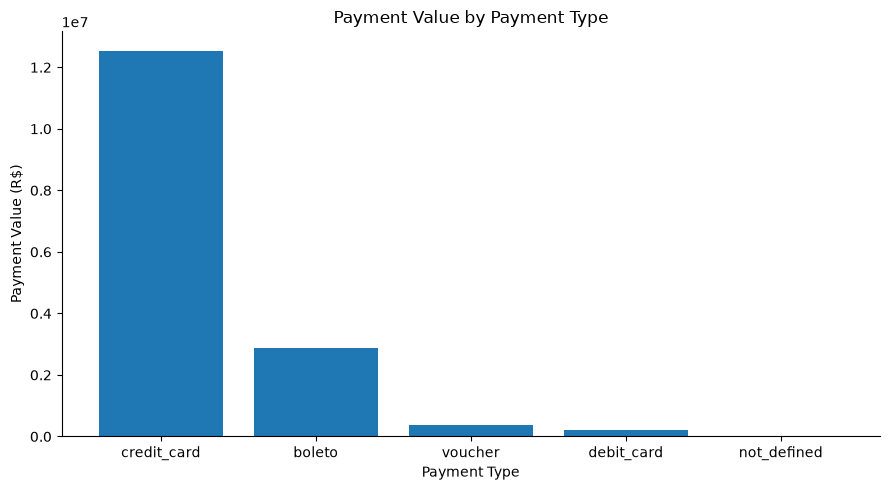

In [18]:
fig, ax = plt.subplots()

ax.bar(
    payment_type_summary.index,
    payment_type_summary['total_payment_value']
)

ax.set_title('Payment Value by Payment Type')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Payment Value (R$)')

plt.tight_layout()
plt.show()

In [19]:
credit_card_installments = payments.loc[
    payments['payment_type'] == 'credit_card',
    'payment_installments'
]

print(f"Average credit-card installments: " f"{credit_card_installments.mean():.1f}")

Average credit-card installments: 3.5


### 7.7 Seller Concentration

Seller order value is analyzed to understand whether marketplace value is broadly
distributed or concentrated among a smaller group of sellers.

A cumulative distribution is used to examine the long-tail structure.

In [20]:
seller_value = (
    delivered
    .groupby('seller_id')['item_total']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='order_value')
)

seller_value['cum_share'] = (
    seller_value['order_value'].cumsum()
    / seller_value['order_value'].sum()
    * 100
)

seller_value['seller_rank_pct'] = (
    (seller_value.index + 1)
    / len(seller_value)
    * 100
)

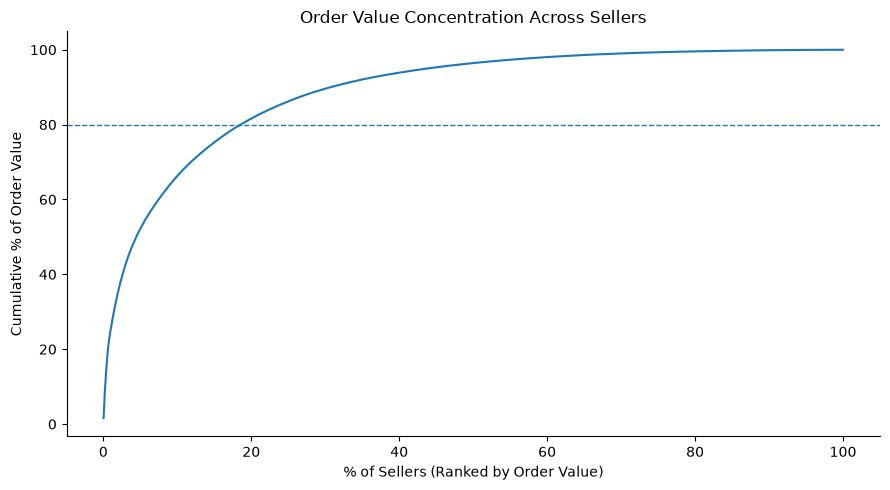

In [21]:
fig, ax = plt.subplots()

ax.plot(
    seller_value['seller_rank_pct'],
    seller_value['cum_share']
)

ax.axhline(
    80,
    linestyle='--',
    linewidth=1
)

ax.set_xlabel('% of Sellers (Ranked by Order Value)')
ax.set_ylabel('Cumulative % of Order Value')
ax.set_title('Order Value Concentration Across Sellers')

plt.tight_layout()
plt.show()

In [22]:
top10pct_cut = (
    seller_value.loc[
        seller_value['seller_rank_pct'] <= 10,
        'order_value'
    ].sum()
    / seller_value['order_value'].sum()
    * 100
)

print(f"Top 10% of sellers account for " f"{top10pct_cut:.1f}% of total order value")
print(f"Distinct sellers with a delivered sale: " f"{len(seller_value):,}")

Top 10% of sellers account for 66.3% of total order value
Distinct sellers with a delivered sale: 2,970


### 7.8 Customer Repeat Behavior

Customer purchase frequency is examined using `customer_unique_id` to distinguish
repeat purchasing behavior from multiple order records belonging to the same
customer.

In [23]:
customer_orders = (
    orders[orders['order_status'] == 'delivered']
    [['customer_id', 'order_id']]
    .merge(
        customers[
            ['customer_id', 'customer_unique_id']
        ],
        on='customer_id',
        how='left'
    )
)

customer_order_counts = (
    customer_orders
    .groupby('customer_unique_id')['order_id']
    .nunique()
    )
repeat_customers = ((customer_order_counts > 1).sum())
total_customers = (customer_order_counts.shape[0])
repeat_rate = (repeat_customers / total_customers * 100)

print(f"Unique delivered customers: {total_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat customer rate: {repeat_rate:.1f}%")

Unique delivered customers: 93,358
Repeat customers: 2,801
Repeat customer rate: 3.0%


> **Note:** The repeat-customer rate describes purchasing behavior within the
> observed dataset period. It should not be interpreted as a complete customer
> retention or lifetime-value measure.

In [24]:
# Key metrics for the final business summary

key_metrics = {
    'delivered_orders': delivered['order_id'].nunique(),
    'late_delivery_rate_pct': late_share,
    'avg_delivery_days': avg_delivery_days,
    'top_state_share_pct': top_state_share,
    'top_3_state_share_pct': top3_share,
    'top_10_seller_value_share_pct': top10pct_cut,
    'repeat_customer_rate_pct': repeat_rate
}

pd.Series(key_metrics).round(2)

delivered_orders                 96478.00
late_delivery_rate_pct               8.11
avg_delivery_days                   12.56
top_state_share_pct                 41.98
top_3_state_share_pct               66.55
top_10_seller_value_share_pct       66.29
repeat_customer_rate_pct             3.00
dtype: float64

## 8. Key Findings

The exploratory analysis identified several business-relevant patterns. Exact values below come from the
**Key Metrics** cell above.

- **Demand:** 96,478 delivered orders were analyzed, with order volume growing steadily through 2017 before
  flattening toward mid-2018 (the edge of the dataset).
- **Geography:** Demand is heavily concentrated — the top state (São Paulo) alone accounts for **41.98%** of
  delivered orders, and the top 3 states together account for **66.55%**.
- **Delivery:** **8.11%** of delivered orders arrived after their estimated delivery date, with an average
  delivery time of **12.56 days**.
- **Customer experience:** Late-delivered orders show a noticeably lower average review score than
  on-time/early orders — the clearest satisfaction signal found in the data.
- **Seller concentration:** The top 10% of sellers (by revenue) account for **66.29%** of total observed item
  value — a classic long-tail distribution.
- **Repeat purchasing:** Only about **3.00%** of unique customers placed more than one order within the
  observed period.

These findings are descriptive and should not be interpreted as causal effects.

## 9. Business Interpretation

### Delivery Reliability

The relationship between delivery timing and review scores suggests that delivery
reliability is an important customer-experience signal.

This creates a potential opportunity for earlier identification of orders that are
at higher risk of missing their estimated delivery date.

### Seller Performance

The concentration of order value among sellers suggests an opportunity to understand
what differentiates stronger-performing sellers and where other sellers may need
support.

### Geographic Demand

The concentration of demand across states can support further analysis of regional
logistics, seller coverage, and delivery performance.

### Customer Repeat Behavior

The observed repeat-purchasing rate provides a useful starting point for customer
behavior analysis, but it should not be treated as a complete retention metric
because the dataset covers a limited historical period.

## 10. HVIA Data & AI Solution Ideas

The findings suggest two potential solution areas that could be explored by HVIA.

The goal is to connect each solution directly to an observed business signal rather
than proposing AI without a clear business problem.

### 10.1 Predictive Delivery Risk System

**Business problem**

A measurable share of delivered orders arrive after their estimated delivery date,
and late orders show a different average review score.

**Proposed solution**

A machine-learning model could estimate the probability that an order will miss its
expected delivery date.

**Potential inputs**

- Seller location
- Customer region
- Product characteristics
- Historical seller delivery performance
- Seasonality and order timing

**Potential actions**

- Early delivery-risk alerts
- Proactive operational intervention
- Improved customer communication
- Seller performance monitoring

> Features should only use information available at the time the prediction is made
> to avoid data leakage.

### 10.2 Seller Growth & Health Analytics

**Business problem**

Observed item value is concentrated among a subset of sellers.

**Proposed solution**

An analytics layer could monitor seller performance and identify improvement
opportunities relative to relevant benchmarks.

**Potential outputs**

- Seller performance indicators
- Growth trends
- Delivery consistency
- Category demand signals
- Action-oriented recommendations

The purpose would be to help Olist identify where targeted seller support could
have the greatest operational or commercial impact.

## 11. Outreach Draft

**Target:** Data, Operations, or Seller Experience decision-maker at Olist

### LinkedIn Message

> Hi [Name],  
> I recently analyzed Olist's public e-commerce dataset as part of an HVIA Data & AI
> Solutions trial task. The analysis highlighted patterns around delivery reliability,
> seller concentration, geographic demand, and repeat purchasing.  
>
> One area I found particularly interesting was the relationship between delivery
> timing and customer review scores. This could potentially be extended into a
> predictive delivery-risk use case.  
>
> I'd be happy to share the analysis and discuss how similar Data & AI solutions
> could support Olist's operations.  
>
> Best,  
> Shahd

## 12. Limitations & Next Steps

### Limitations

- The dataset covers a historical period from 2016 to 2018.
- It does not provide current Olist operational data.
- The analysis shows associations rather than causal relationships.
- Some variables contain missing values, particularly review text fields and
  certain delivery timestamps.
- Repeat purchasing is measured only within the observed dataset period.

### Next Steps

Future analysis could incorporate:

- Real-time logistics data
- Current seller performance data
- More detailed customer behavior
- Operational cost data
- Additional marketplace and marketing signals

## 13. Conclusion

This analysis followed the workflow:

**Understand → Analyze → Propose → Pitch**

The dataset was first examined to understand Olist's business ecosystem and table
relationships. Exploratory analysis was then used to identify patterns in demand,
delivery, customer satisfaction, seller performance, payment behavior, and repeat
purchasing.

The main opportunities identified focus on predictive delivery-risk monitoring and
seller performance analytics.

These opportunities illustrate how operational data can be translated into
actionable business and Data & AI solutions.